In [1]:
import pandas as pd

df_val = pd.read_csv("raw_data/player_valuations.csv")
df_val.head()

,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [2]:
df_val.columns = (
    df_val.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w\s]", "", regex=True)
)

In [9]:
df_val['date'] = pd.to_datetime(df_val['date'], errors='coerce')

In [4]:
df_val['date'].isna().sum()

np.int64(0)

In [5]:
df_val = df_val.dropna(subset=['date'])

<Axes: ylabel='Frequency'>

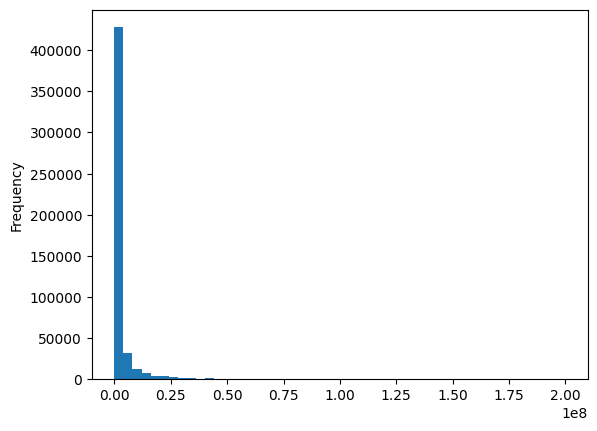

In [6]:
df_val['market_value_in_eur'].describe()
df_val['market_value_in_eur'].plot(kind='hist', bins=50)

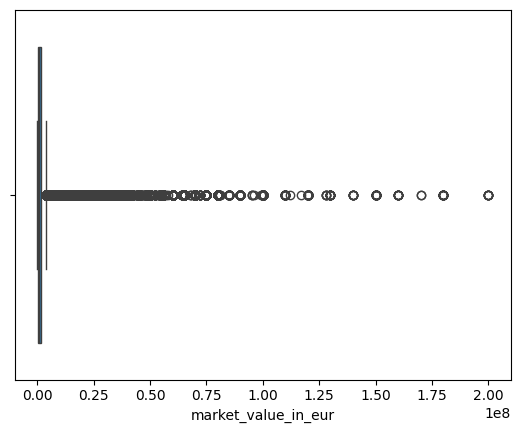

In [7]:
# visualizing extreme values
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df_val['market_value_in_eur'])
plt.show()

# filtering out top 0.5% extreme values
upper_limit = df_val['market_value_in_eur'].quantile(0.995)
df_val = df_val[df_val['market_value_in_eur'] <= upper_limit]

In [10]:
# checking for duplicates
duplicate_count = df_val.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

# dropping duplicates
df_val = df_val.drop_duplicates()

Duplicate rows: 0


In [11]:
# summary of missing values
missing_summary = df_val.isna().sum()
print(missing_summary)

player_id                              0
date                                   0
market_value_in_eur                    0
current_club_id                        0
player_club_domestic_competition_id    0
dtype: int64


In [12]:
# checking for negatives or unrealistic values
print(df_val['market_value_in_eur'].describe())
print(df_val['player_id'].nunique(), 'unique players')
print(df_val['date'].min(), 'to', df_val['date'].max())

count    4.941650e+05
mean     2.137634e+06
std      4.845812e+06
min      0.000000e+00
25%      2.000000e+05
50%      5.000000e+05
75%      1.600000e+06
max      4.800000e+07
Name: market_value_in_eur, dtype: float64
31078 unique players
2000-01-20 00:00:00 to 2025-04-06 00:00:00


In [13]:
# checking for unrealistic low values
df_val[df_val['market_value_in_eur'] < 1000]

,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
15331,60096,2008-03-17,0,2696,RU1


In [14]:
# removing entries with zero or extremely low market values
df_val = df_val[df_val['market_value_in_eur'] >= 1000]

In [15]:
df_val['player_club_domestic_competition_id'].value_counts(dropna=False)
df_val['current_club_id'].value_counts().head(10)

current_club_id
2381    3009
126     2821
589     2811
252     2806
2293    2720
800     2577
276     2526
1025    2480
2672    2475
410     2420
Name: count, dtype: int64

<Axes: xlabel='year'>

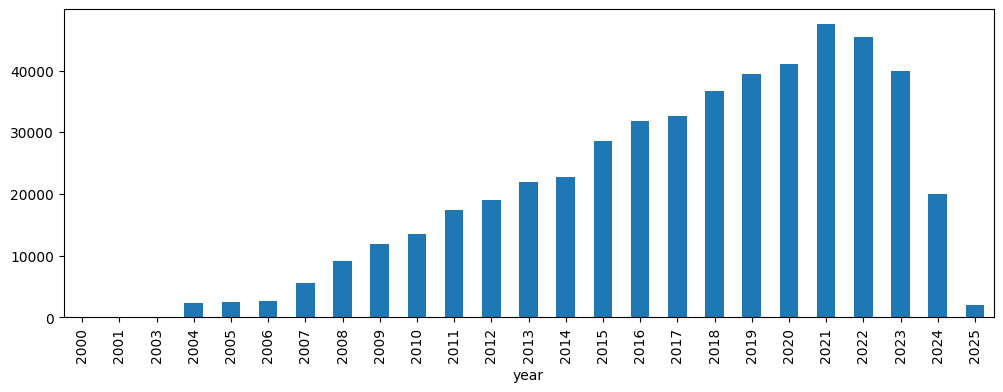

In [16]:
df_val['year'] = df_val['date'].dt.year
df_val['year'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))

In [17]:
df_val.info()
df_val.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 494164 entries, 0 to 496605
Data columns (total 6 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   player_id                            494164 non-null  int64         
 1   date                                 494164 non-null  datetime64[ns]
 2   market_value_in_eur                  494164 non-null  int64         
 3   current_club_id                      494164 non-null  int64         
 4   player_club_domestic_competition_id  494164 non-null  object        
 5   year                                 494164 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(1)
memory usage: 24.5+ MB


player_id                              0
date                                   0
market_value_in_eur                    0
current_club_id                        0
player_club_domestic_competition_id    0
year                                   0
dtype: int64

In [18]:
for col in df_val.columns:
    print(f"{col}: {df_val[col].nunique()} unique values")
    print(df_val[col].value_counts(dropna=False).head(), "\n")

player_id: 31078 unique values
player_id
39333    54
57162    51
18829    49
27306    49
54148    49
Name: count, dtype: int64 

date: 5316 unique values
date
2020-04-08    10406
2015-07-01     4095
2016-07-15     2954
2020-12-29     1771
2023-06-26     1711
Name: count, dtype: int64 

market_value_in_eur: 386 unique values
market_value_in_eur
300000    27849
200000    27419
100000    27303
500000    24707
50000     24568
Name: count, dtype: int64 

current_club_id: 437 unique values
current_club_id
2381    3009
126     2821
589     2811
252     2806
2293    2720
Name: count, dtype: int64 

player_club_domestic_competition_id: 14 unique values
player_club_domestic_competition_id
TR1    56143
IT1    54528
ES1    40842
GR1    40664
L1     37698
Name: count, dtype: int64 

year: 25 unique values
year
2021    47552
2022    45522
2020    41032
2023    39964
2019    39417
Name: count, dtype: int64 



<Axes: xlabel='log_value', ylabel='Count'>

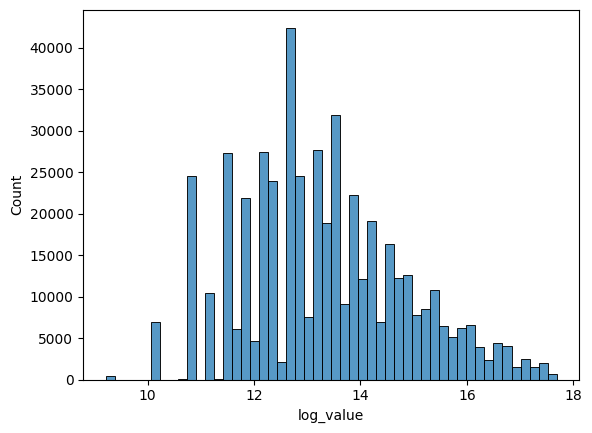

In [19]:
import numpy as np
import seaborn as sns

df_val['log_value'] = np.log1p(df_val['market_value_in_eur'])
sns.histplot(df_val['log_value'], bins=50)

/var/folders/28/s218wsj97vn5fjpfm20pk5_h0000gn/T/ipykernel_2479/393916029.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_val.set_index('date').resample('Y').size().plot(title="Entries per year")


<Axes: title={'center': 'Entries per year'}, xlabel='date'>

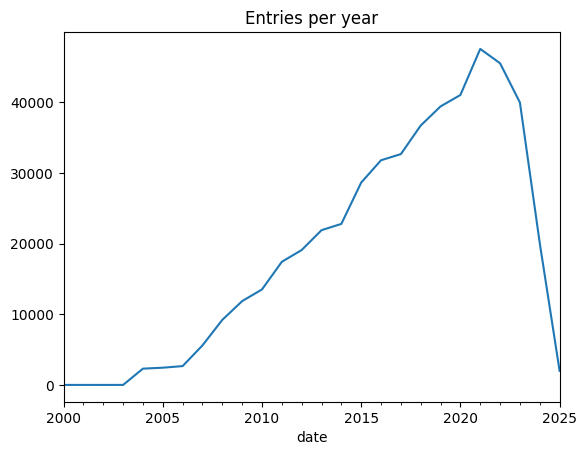

In [20]:
df_val.set_index('date').resample('Y').size().plot(title="Entries per year")

In [22]:
df_val.to_csv("backend/clean_data/cleaned_player_valuations.csv", index=False)